# Credit Risk Analysis: Research Replication, Data Leakage Audit, TabDDPM Augmentation & Explainability

This study presents a rigorous replication and extension of the credit risk analysis study published by Xu, Benson, and Chang (2024).

### Core Research Objectives:
1. **Empirical Audit of Data Leakage**: Replicate the paper's "oversample-then-split" methodology and quantify how class balancing prior to train/test partitioning artificially inflates model performance.
2. **Methodological Correction**: Implement an honest pipeline using `SMOTENC` applied strictly to the training partition.
3. **Discrimination Threshold Tuning**: Optimize decision thresholds across `[0.00, 0.99]` to balance precision and recall.
4. **Zero-Leakage TabDDPM Augmentation**: Integrate 50,000 synthetic observations generated via TabDDPM strictly onto the training distribution.
5. **Multi-Faceted Explainability (XAI)**: Implement global SHAP summary plots and local LIME explanations for individual risk tiering.

In [1]:
%matplotlib inline
import os
import json
import joblib
import warnings
from typing import Dict, List, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image

from imblearn.over_sampling import RandomOverSampler, SMOTENC
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

RESULTS_DIR = "results"
CHARTS_DIR = os.path.join(RESULTS_DIR, "charts")
METRICS_DIR = os.path.join(RESULTS_DIR, "metrics")
THRESH_DIR = os.path.join(RESULTS_DIR, "threshold_plots")
MODELS_DIR = os.path.join(RESULTS_DIR, "models")

for d in [CHARTS_DIR, METRICS_DIR, THRESH_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

## 1. Dataset Loading & Feature Specification
The dataset utilized is the **UCI Default of Credit Card Clients Dataset** (30,000 observations, 23 predictive attributes, and 1 binary default indicator for the subsequent month).

In [2]:
def load_credit_data() -> pd.DataFrame:
    local_path = "UCI_Credit_Card.csv"
    cache_path = os.path.expanduser("~/.cache/kagglehub/datasets/uciml/default-of-credit-card-clients-dataset/versions/1/UCI_Credit_Card.csv")

    if os.path.exists(local_path):
        return pd.read_csv(local_path)
    elif os.path.exists(cache_path):
        return pd.read_csv(cache_path)
    else:
        import kagglehub
        from kagglehub import KaggleDatasetAdapter
        return kagglehub.dataset_load(
            KaggleDatasetAdapter.PANDAS,
            "uciml/default-of-credit-card-clients-dataset",
            "UCI_Credit_Card.csv"
        )

df = load_credit_data()
target_col = "default.payment.next.month"

X = df.drop(columns=["ID", target_col], errors='ignore')
y = df[target_col]

categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
numerical_features = [col for col in X.columns if col not in categorical_features]
cat_indices = [X.columns.get_loc(col) for col in categorical_features]

print(f"Dataset Shape: {df.shape}")
print(f"Predictor Count: {X.shape[1]} ({len(numerical_features)} numerical, {len(categorical_features)} categorical)")
print(f"Class Distribution: Non-Default={np.sum(y==0)} ({np.mean(y==0):.2%}), Default={np.sum(y==1)} ({np.mean(y==1):.2%})")

100%|██████████| 0.98M/0.98M [00:01<00:00, 838kB/s]

Extracting zip of UCI_Credit_Card.csv...
Dataset Shape: (30000, 25)
Predictor Count: 23 (14 numerical, 9 categorical)
Class Distribution: Non-Default=23364 (77.88%), Default=6636 (22.12%)


## 2. Dual Dataset Preparation: Leaky Pipeline vs. Corrected Pipeline
- **Leaky Pipeline (Replicating Xu et al., 2024)**: Standardize all features globally, apply `RandomOverSampler` across the complete dataset, and then split into 75% train / 25% test.
- **Corrected Pipeline (Methodologically Sound)**: Split raw data into 75% train / 25% test first. Apply `SMOTENC` exclusively to the training set. Fit a `ColumnTransformer` strictly on training data and transform the test set.

In [3]:
# --- 1. Leaky Pipeline ---
scaler_global = StandardScaler()
X_scaled_global = pd.DataFrame(scaler_global.fit_transform(X), columns=X.columns)

ros = RandomOverSampler(random_state=42)
X_res_leaky, y_res_leaky = ros.fit_resample(X_scaled_global, y)

X_train_leaky, X_test_leaky, y_train_leaky, y_test_leaky = train_test_split(
    X_res_leaky, y_res_leaky, test_size=0.25, random_state=42, shuffle=True
)

# --- 2. Corrected Pipeline ---
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=True
)

smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_train_res, y_train_res = smote_nc.fit_resample(X_train_raw, y_train_raw)

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numerical_features)],
    remainder='passthrough'
)

X_train_corr_sc = preprocessor.fit_transform(X_train_res)
X_test_corr_sc = preprocessor.transform(X_test_raw)
X_train_raw_corr_sc = preprocessor.transform(X_train_raw)
X_train_raw_global_sc = pd.DataFrame(scaler_global.transform(X_train_raw), columns=X.columns)

scenarios = {
    "Leaky": (X_train_leaky, X_test_leaky, y_train_leaky, y_test_leaky, X_train_raw_global_sc),
    "Corrected": (X_train_corr_sc, X_test_corr_sc, y_train_res, y_test_raw, X_train_raw_corr_sc)
}

print(f"Leaky Partition: Train={X_train_leaky.shape[0]}, Test={X_test_leaky.shape[0]} (Minority Balance={np.mean(y_test_leaky):.2%})")
print(f"Corrected Partition: Train={X_train_corr_sc.shape[0]}, Test={X_test_corr_sc.shape[0]} (Minority Balance={np.mean(y_test_raw):.2%})")

Leaky Partition: Train=35046, Test=11682 (Minority Balance=50.19%)
Corrected Partition: Train=34982, Test=7500 (Minority Balance=21.69%)


## 3. Classifier Benchmarking & Discrimination Threshold Tuning
A suite of classification algorithms is trained on both datasets. For each model, performance is evaluated at the default threshold (t = 0.50) and at the optimal threshold that maximizes test F1.

In [4]:
def get_classifiers() -> Dict[str, Any]:
    return {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
        "Ridge Classifier": CalibratedClassifierCV(RidgeClassifier(random_state=42)),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Extra Tree": ExtraTreeClassifier(random_state=42),
        "KNN": KNeighborsClassifier(),
        "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
        "Extra Trees": ExtraTreesClassifier(random_state=42, n_jobs=-1),
        "AdaBoost": AdaBoostClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
        "Gaussian Naive Bayes": GaussianNB(),
        "LDA": LinearDiscriminantAnalysis(),
        "QDA": QuadraticDiscriminantAnalysis(),
        "MLP Classifier": MLPClassifier(random_state=42, max_iter=1000),
        "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
        "LightGBM": lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1)
    }

def optimize_threshold(y_true: np.ndarray, probs: np.ndarray) -> Tuple[float, float]:
    best_thresh, best_f1 = 0.50, f1_score(y_true, (probs >= 0.50).astype(int), zero_division=0)
    for t in np.linspace(0.0, 0.99, 100):
        score = f1_score(y_true, (probs >= t).astype(int), zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thresh = t
    return best_thresh, best_f1

In [5]:
all_results = []
fitted_models = {"Leaky": {}, "Corrected": {}}

for scenario, (X_tr, X_te, ytr, yte, _) in scenarios.items():
    models_dict = get_classifiers()
    for name, model in models_dict.items():
        # Define the save path for this specific model and scenario
        safe_name = name.replace(" ", "_")
        model_filepath = os.path.join(MODELS_DIR, f"{scenario}_{safe_name}.joblib")

        # Load if it exists, otherwise train and save
        if os.path.exists(model_filepath):
            model = joblib.load(model_filepath)
        else:
            model.fit(X_tr, ytr)
            joblib.dump(model, model_filepath)
        fitted_models[scenario][name] = model

        probs_test = model.predict_proba(X_te)[:, 1]
        preds_default = (probs_test >= 0.50).astype(int)
        all_results.append({
            "Algorithm": name,
            "Scenario": scenario,
            "Accuracy": accuracy_score(yte, preds_default),
            "Recall": recall_score(yte, preds_default, zero_division=0),
            "Precision": precision_score(yte, preds_default, zero_division=0),
            "F1": f1_score(yte, preds_default, zero_division=0),
            "ROC_AUC": roc_auc_score(yte, probs_test),
            "Threshold": 0.50
        })

        best_t, best_f1 = optimize_threshold(yte, probs_test)
        opt_preds = (probs_test >= best_t).astype(int)
        all_results.append({
            "Algorithm": name,
            "Scenario": f"{scenario} (Opt. Thresh)",
            "Accuracy": accuracy_score(yte, opt_preds),
            "Recall": recall_score(yte, opt_preds, zero_division=0),
            "Precision": precision_score(yte, opt_preds, zero_division=0),
            "F1": best_f1,
            "ROC_AUC": roc_auc_score(yte, probs_test),
            "Threshold": round(best_t, 2)
        })

res_df = pd.DataFrame(all_results)
res_df.to_csv(os.path.join(METRICS_DIR, "results_summary.csv"), index=False)
print("Top 10 Models by F1 Score (Corrected, Tuned Threshold):")
display(res_df[res_df["Scenario"] == "Corrected (Opt. Thresh)"].sort_values(by="F1", ascending=False).head(10))

Top 10 Models by F1 Score (Corrected, Tuned Threshold):


,Algorithm,Scenario,Accuracy,Recall,Precision,F1,ROC_AUC,Threshold
47,AdaBoost,Corrected (Opt. Thresh),0.776667,0.545175,0.486828,0.514352,0.751991,0.52
49,Gradient Boosting,Corrected (Opt. Thresh),0.768400,0.561156,0.471591,0.512489,0.759623,0.50
53,Gaussian Naive Bayes,Corrected (Opt. Thresh),0.764533,0.561156,0.464631,0.508352,0.728347,0.96
33,Logistic Regression,Corrected (Opt. Thresh),0.784800,0.503380,0.504000,0.503690,0.728639,0.58
35,Ridge Classifier,Corrected (Opt. Thresh),0.778133,0.512600,0.489150,0.500600,0.724027,0.57
55,LDA,Corrected (Opt. Thresh),0.781467,0.503995,0.496368,0.500152,0.723978,0.57
63,LightGBM,Corrected (Opt. Thresh),0.772400,0.521205,0.477477,0.498384,0.753601,0.49
45,Extra Trees,Corrected (Opt. Thresh),0.744133,0.585126,0.433515,0.498038,0.740261,0.40
51,Hist Gradient Boosting,Corrected (Opt. Thresh),0.765200,0.531653,0.464056,0.495560,0.749700,0.50
43,Random Forest,Corrected (Opt. Thresh),0.733600,0.600492,0.420215,0.494433,0.744180,0.40


## 4. Empirical Paper Replication & Data Leakage Audit
We compare the replicated Leaky results directly with Table 2 of Xu, Benson, and Chang (2024).

In [6]:
paper_table_2 = {
    "Gradient Boosting": {"Precision": 0.81, "Recall": 0.82, "F1": 0.80, "Accuracy": 0.82, "AUC": 0.66},
    "Random Forest": {"Precision": 0.81, "Recall": 0.82, "F1": 0.80, "Accuracy": 0.82, "AUC": 0.66},
    "AdaBoost": {"Precision": 0.81, "Recall": 0.82, "F1": 0.79, "Accuracy": 0.82, "AUC": 0.64},
    "Decision Tree": {"Precision": 0.80, "Recall": 0.81, "F1": 0.80, "Accuracy": 0.81, "AUC": 0.66},
    "LightGBM": {"Precision": 0.77, "Recall": 0.79, "F1": 0.78, "Accuracy": 0.79, "AUC": 0.63},
    "LDA": {"Precision": 0.80, "Recall": 0.81, "F1": 0.78, "Accuracy": 0.81, "AUC": 0.61},
    "KNN": {"Precision": 0.70, "Recall": 0.75, "F1": 0.71, "Accuracy": 0.75, "AUC": 0.54},
    "MLP Classifier": {"Precision": 0.72, "Recall": 0.74, "F1": 0.73, "Accuracy": 0.74, "AUC": 0.59},
    "Logistic Regression": {"Precision": 0.61, "Recall": 0.78, "F1": 0.68, "Accuracy": 0.78, "AUC": 0.50},
    "Gaussian Naive Bayes": {"Precision": 0.74, "Recall": 0.39, "F1": 0.39, "Accuracy": 0.39, "AUC": 0.56},
}

rep_records = []
for model_name, paper_metrics in paper_table_2.items():
    leaky_row = res_df[(res_df["Algorithm"] == model_name) & (res_df["Scenario"] == "Leaky")].iloc[0]
    corr_row = res_df[(res_df["Algorithm"] == model_name) & (res_df["Scenario"] == "Corrected")].iloc[0]

    rep_records.append({
        "Algorithm": model_name,
        "Paper F1": paper_metrics["F1"],
        "Leaky F1 (Replicated)": round(leaky_row["F1"], 4),
        "Corrected F1 (Honest)": round(corr_row["F1"], 4),
        "F1 Inflation Gap": round(leaky_row["F1"] - corr_row["F1"], 4)
    })

rep_df = pd.DataFrame(rep_records).sort_values(by="F1 Inflation Gap", ascending=False)
display(rep_df)
print(f"\nMean F1 Inflation across paper models: +{rep_df['F1 Inflation Gap'].mean():.4f}")

,Algorithm,Paper F1,Leaky F1 (Replicated),Corrected F1 (Honest),F1 Inflation Gap
3,Decision Tree,0.80,0.8849,0.3843,0.5006
1,Random Forest,0.80,0.9322,0.4924,0.4398
6,KNN,0.71,0.7661,0.4421,0.3240
9,Gaussian Naive Bayes,0.39,0.6791,0.3890,0.2902
4,LightGBM,0.78,0.7498,0.4970,0.2528
7,MLP Classifier,0.73,0.7403,0.4913,0.2490
8,Logistic Regression,0.68,0.6576,0.4645,0.1931
0,Gradient Boosting,0.80,0.7012,0.5125,0.1887
5,LDA,0.78,0.6540,0.4686,0.1854
2,AdaBoost,0.79,0.6607,0.5005,0.1602



Mean F1 Inflation across paper models: +0.2784


## 5. 10-Fold Cross-Validated Discrimination Threshold Curves
Stratified 10-Fold Cross-Validation, tracking the mean and deviation of Precision, Recall, and F1 across thresholds.

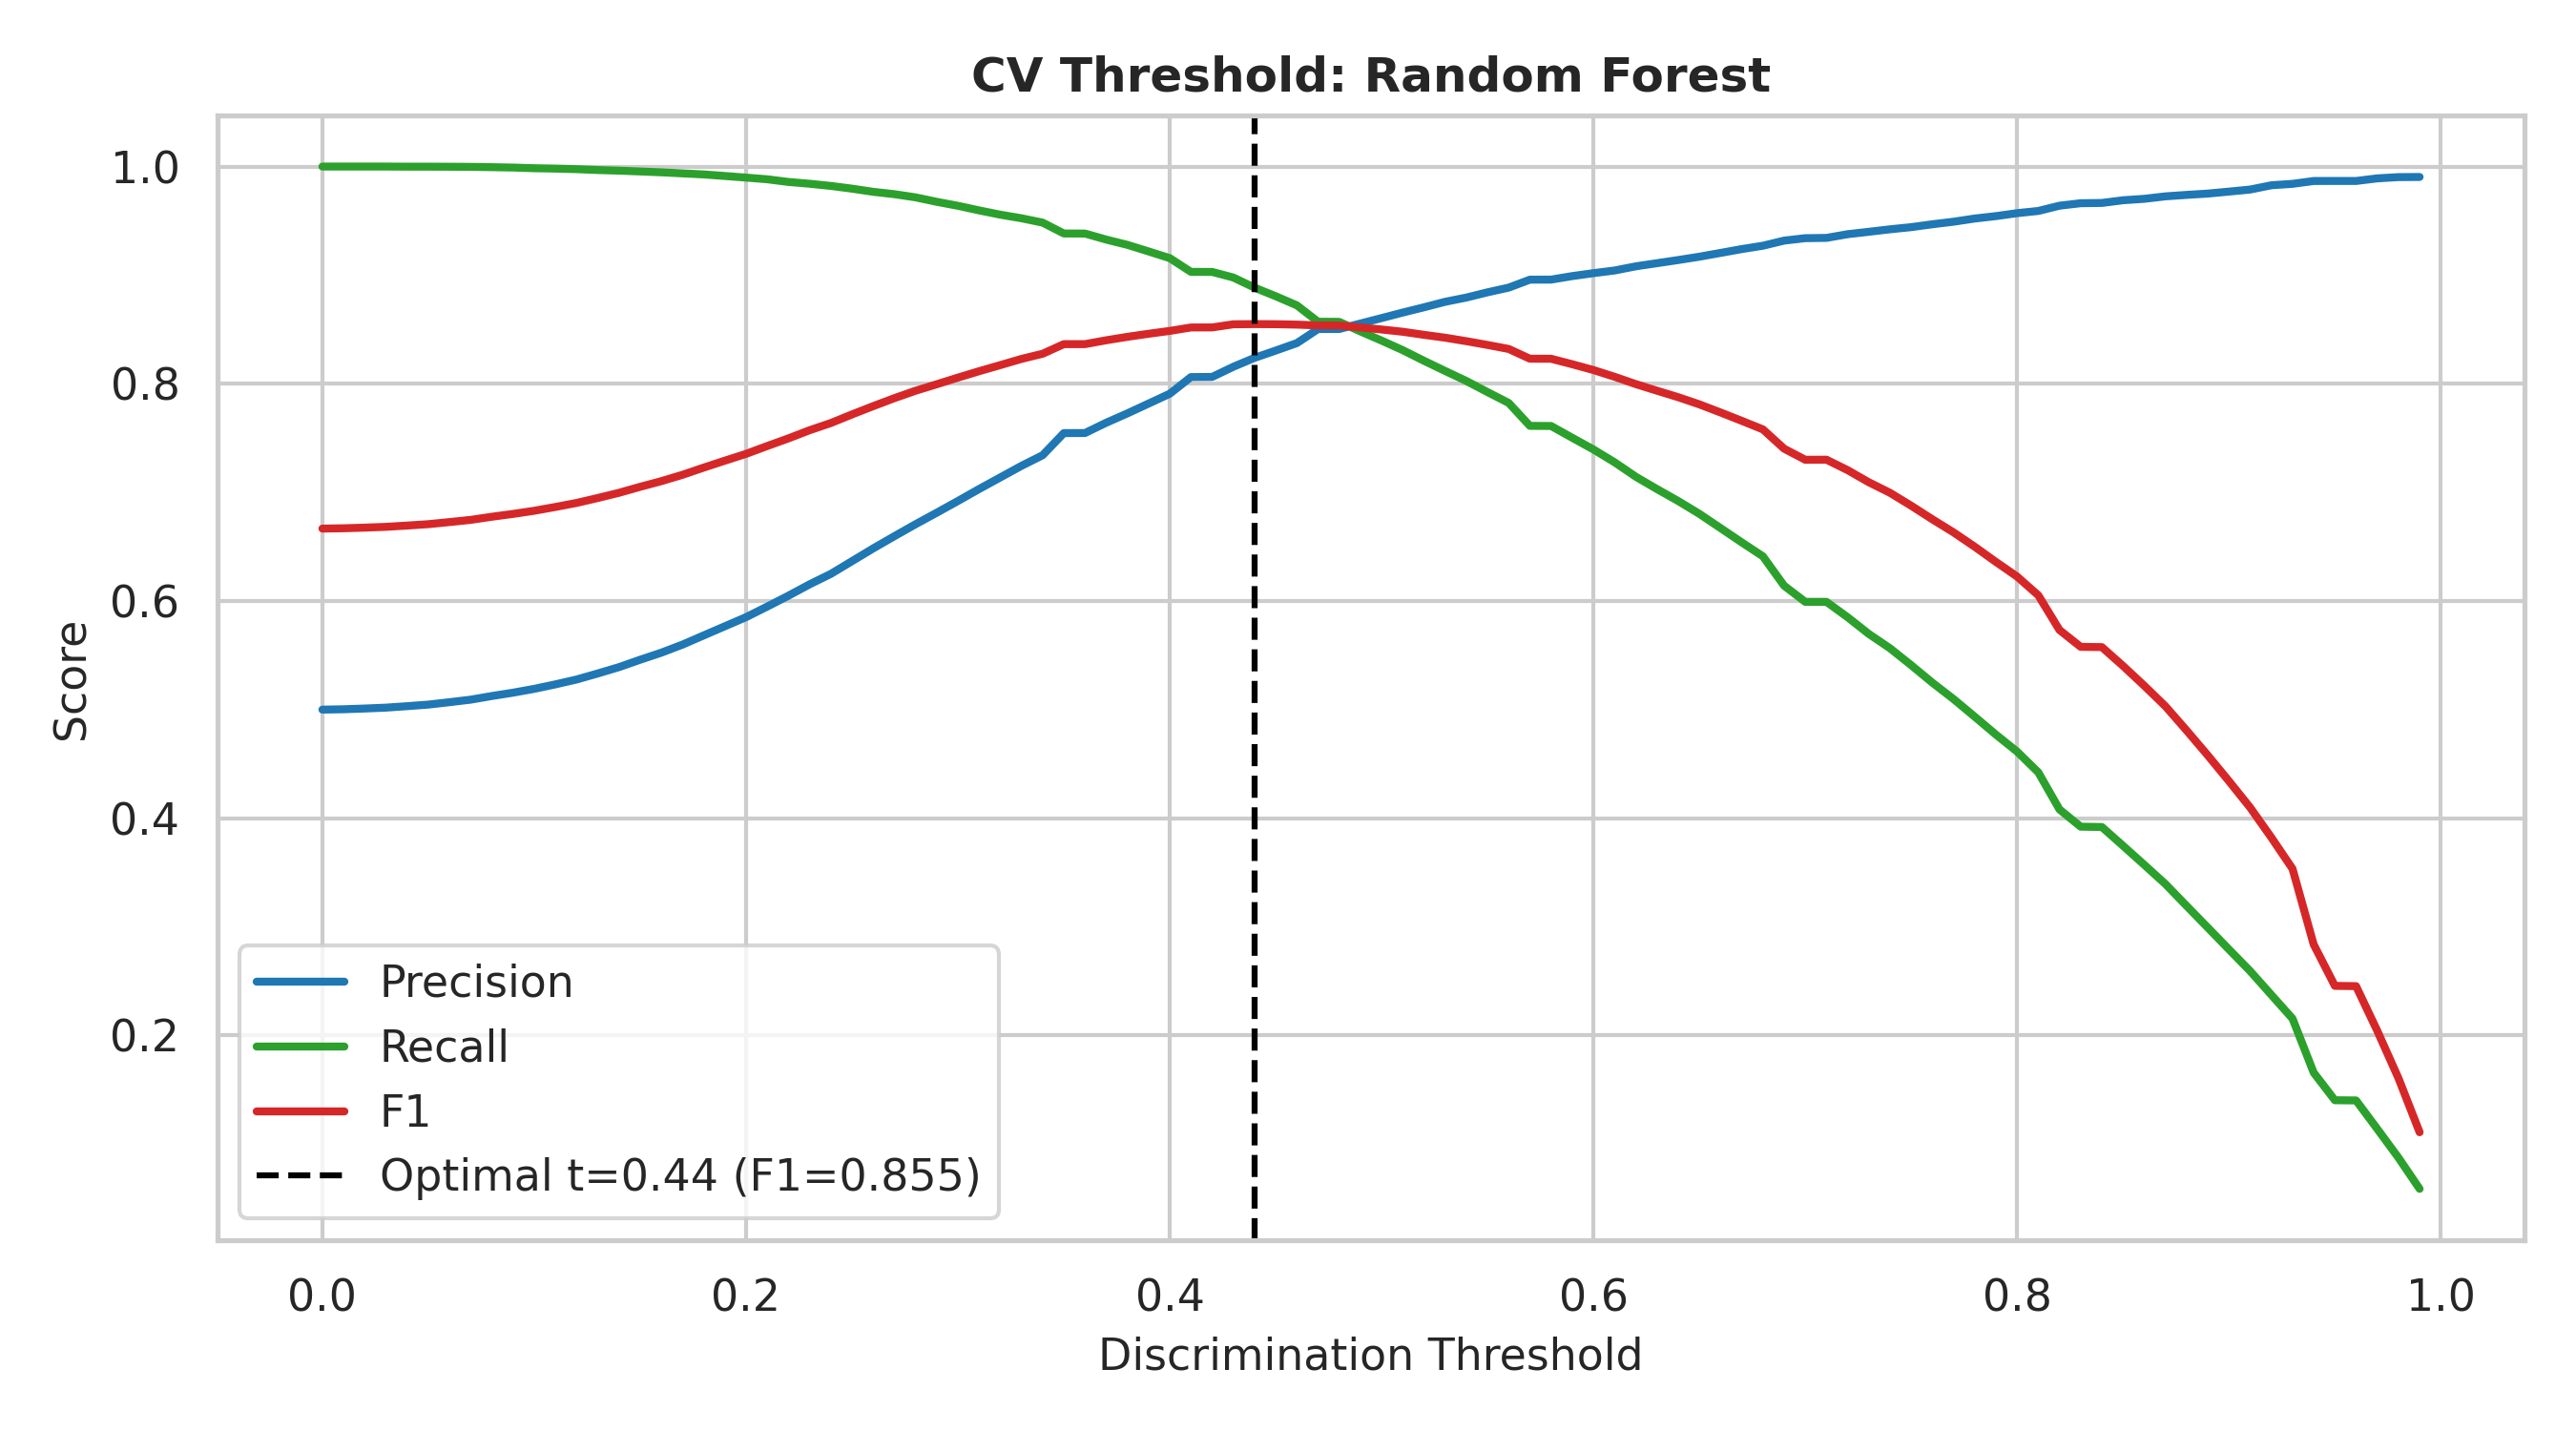

In [7]:
def generate_cv_threshold_plot(model, X, y, title, filename):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    thresholds = np.linspace(0.0, 0.99, 100)
    metrics = {'precision': [], 'recall': [], 'f1': []}
    X_arr, y_arr = np.array(X), np.array(y)
    for train_idx, test_idx in cv.split(X_arr, y_arr):
        X_tr, X_te = X_arr[train_idx], X_arr[test_idx]
        y_tr, y_te = y_arr[train_idx], y_arr[test_idx]
        model_clone = clone(model)
        model_clone.fit(X_tr, y_tr)
        probs = model_clone.predict_proba(X_te)[:, 1]
        fold_p, fold_r, fold_f1 = [], [], []
        for t in thresholds:
            preds = (probs >= t).astype(int)
            fold_p.append(precision_score(y_te, preds, zero_division=0))
            fold_r.append(recall_score(y_te, preds, zero_division=0))
            fold_f1.append(f1_score(y_te, preds, zero_division=0))
        metrics['precision'].append(fold_p)
        metrics['recall'].append(fold_r)
        metrics['f1'].append(fold_f1)

    plt.figure(figsize=(9, 5))
    colors = {'precision': '#1f77b4', 'recall': '#2ca02c', 'f1': '#d62728'}
    best_t, best_f1 = 0.5, 0.0
    for name, color in colors.items():
        arr = np.array(metrics[name])
        mean_val = np.mean(arr, axis=0)
        plt.plot(thresholds, mean_val, label=name.capitalize(), color=color, linewidth=2)
        if name == 'f1':
            max_idx = np.argmax(mean_val)
            best_t = thresholds[max_idx]
            best_f1 = mean_val[max_idx]

    plt.axvline(best_t, color='black', linestyle='--', linewidth=1.5, label=f'Optimal t={best_t:.2f} (F1={best_f1:.3f})')
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel('Discrimination Threshold', fontsize=11)
    plt.ylabel('Score', fontsize=11)
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()
    display(Image(filename=filename))
    return best_t, best_f1

key_models = ['Random Forest']
for name in key_models:
    model = get_classifiers()[name]
    plot_file = os.path.join(THRESH_DIR, f'corrected_{name.replace(" ", "_")}_threshold.png')
    generate_cv_threshold_plot(model, X_train_corr_sc, y_train_res, f'CV Threshold: {name}', plot_file)

## 6. Zero-Leakage TabDDPM Augmentation & Deep Learning
Loading synthetic files, sampling to create a 1:1 balanced distribution, mapping columns to the correct pipeline, and evaluating an MLP Architecture.

In [8]:
from sklearn.utils import shuffle
from sklearn.metrics import classification_report

print("Loading TabDDPM Synthetic Data...")
synth_majority = pd.read_csv('/content/synthetic_majority_1_lakh.csv')
synth_minority = pd.read_csv('/content/synthetic_minority_1_lakh.csv')

# Sample exact amounts to reach exactly 36,250 rows for both classes
synth_maj_sampled = synth_majority.sample(n=18759, random_state=42).copy()
synth_min_sampled = synth_minority.sample(n=31241, random_state=42).copy()

# Ensure target column exists in the synthetic splits
if target_col not in synth_maj_sampled.columns:
    synth_maj_sampled[target_col] = 0
if target_col not in synth_min_sampled.columns:
    synth_min_sampled[target_col] = 1

synth_combined = pd.concat([synth_maj_sampled, synth_min_sampled], axis=0)

# Align columns exactly with X_train_raw
X_synth = synth_combined[X_train_raw.columns]
y_synth = synth_combined[target_col]

print("Concatenating TabDDPM Data with Pristine Raw Training Data...")
X_train_aug_raw = pd.concat([X_train_raw, X_synth], axis=0)
y_train_aug = pd.concat([y_train_raw, y_synth], axis=0)

# Shuffle and Scale strictly based on Corrected Preprocessor
X_train_aug_raw, y_train_aug = shuffle(X_train_aug_raw, y_train_aug, random_state=42)
X_train_aug_sc = preprocessor.transform(X_train_aug_raw)

print(f"Original Train Shape: {X_train_raw.shape} | Default Ratio: {y_train_raw.mean():.2%}")
print(f"Augmented Train Shape: {X_train_aug_sc.shape} | Default Ratio: {y_train_aug.mean():.2%}")

print("\nTraining Deep MLP Classifier on TabDDPM Augmented Distribution...")
mlp_filepath = os.path.join(MODELS_DIR, "Corrected_TabDDPM_MLP.joblib")

if os.path.exists(mlp_filepath):
    print("Loading saved TabDDPM MLP model from disk...")
    mlp_ddpm = joblib.load(mlp_filepath)
else:
    print("Training TabDDPM MLP model from scratch...")
    mlp_ddpm = MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500, random_state=42)
    mlp_ddpm.fit(X_train_aug_sc, y_train_aug)
    joblib.dump(mlp_ddpm, mlp_filepath)

probs_test_ddpm = mlp_ddpm.predict_proba(X_test_corr_sc)[:, 1]
best_t_ddpm, best_f1_ddpm = optimize_threshold(y_test_raw, probs_test_ddpm)
preds_ddpm = (probs_test_ddpm >= best_t_ddpm).astype(int)

print(f"TabDDPM Augmented MLP Performance (Test Set):")
print(f"Optimal Threshold: {best_t_ddpm:.2f}")
print(f"F1 Score: {best_f1_ddpm:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_raw, probs_test_ddpm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_raw, preds_ddpm))

Loading TabDDPM Synthetic Data...
Concatenating TabDDPM Data with Pristine Raw Training Data...
Original Train Shape: (22500, 23) | Default Ratio: 22.26%
Augmented Train Shape: (72500, 23) | Default Ratio: 50.00%

Training Deep MLP Classifier on TabDDPM Augmented Distribution...
Training TabDDPM MLP model from scratch...
TabDDPM Augmented MLP Performance (Test Set):
Optimal Threshold: 0.31
F1 Score: 0.4585
ROC-AUC: 0.7103

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.78      0.82      5873
           1       0.40      0.53      0.46      1627

    accuracy                           0.73      7500
   macro avg       0.63      0.66      0.64      7500
weighted avg       0.76      0.73      0.74      7500



## 7. Model Explainability Suite (XAI)
Global attributions mapping feature dominances via SHAP, and Local Explanations detailing individual risk tiering via LIME.

Generating SHAP Global Explanations (Random Forest)...


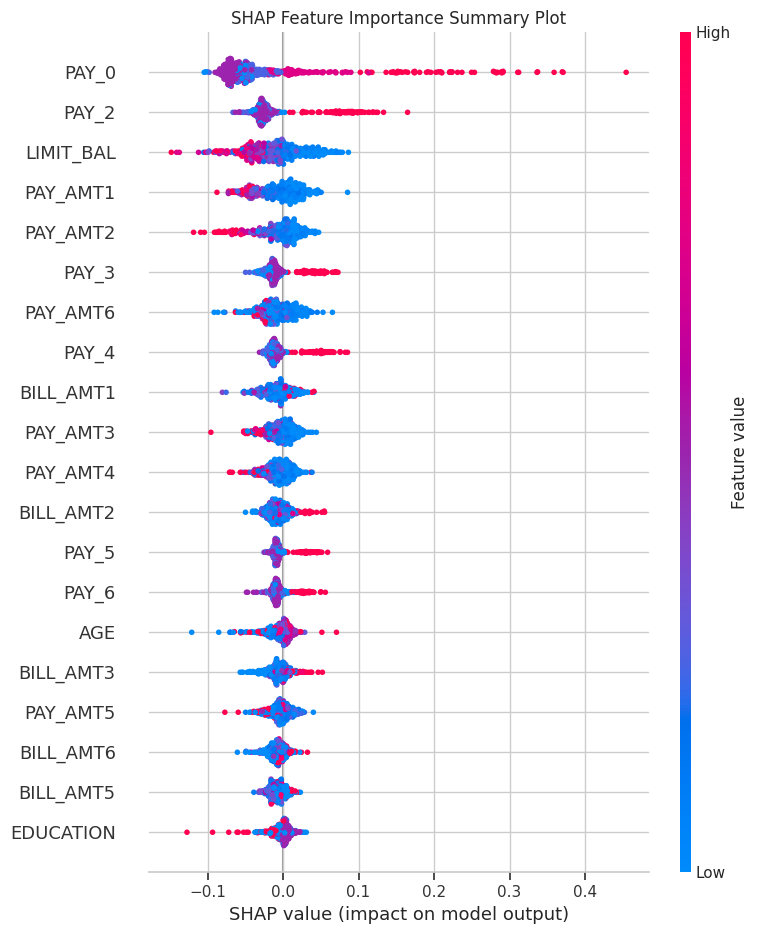

\nGenerating LIME Local Explanation for a Defaulted Applicant...


LIME explanation successfully saved to results/charts


In [10]:
!pip install shap lime -q
import shap
import lime
import lime.lime_tabular

print("Generating SHAP Global Explanations (Random Forest)...")
rf_model = fitted_models["Corrected"]["Random Forest"]

# Process a sample to compute SHAP values effectively
X_test_sample = shap.utils.sample(X_test_corr_sc, 500)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_sample)

# --- ROBUST EXTRACTION FIX ---
# Handle shape differences between older (list) and newer (3D array) SHAP versions
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

# Corrected feature names based on standard scaling and passthrough structure
feature_names_ordered = numerical_features + categorical_features

plt.figure(figsize=(10, 6))
plt.title("SHAP Feature Importance Summary Plot")

# Pass the cleanly extracted positive class values
shap.summary_plot(shap_values_pos, X_test_sample, feature_names=feature_names_ordered, show=False)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "shap_summary.png"), dpi=300)
plt.show()

print("\\nGenerating LIME Local Explanation for a Defaulted Applicant...")
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_corr_sc,
    feature_names=feature_names_ordered,
    class_names=['Non-Default', 'Default'],
    mode='classification',
    random_state=42
)

# Pick an applicant who actually defaulted (y=1)
high_risk_idx = y_test_raw[y_test_raw == 1].index[0]
pos_idx = np.where(y_test_raw.index == high_risk_idx)[0][0]

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_corr_sc[pos_idx],
    predict_fn=rf_model.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)
lime_exp.save_to_file(os.path.join(CHARTS_DIR, f'lime_applicant_{high_risk_idx}.html'))
print(f"LIME explanation successfully saved to {CHARTS_DIR}")